In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

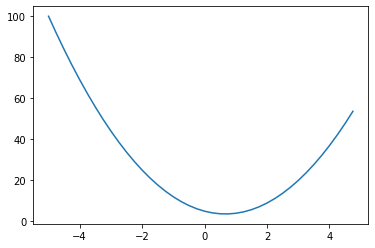

In [3]:
#create inputs
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys, "")

In [4]:
#calculating derivative
h = 0.00001
x = 4
(f(x+h) - f(x))/h

20.00002999835715

In [5]:
#more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d

4.0

In [6]:
#what's the derivative of d wrt. a, b, c
h = 0.0001

d1 = a*b + c
a += h #nudge a by a little bit
d2 = a*b + c
slope = (d2-d1)/h
print("slope is " + f"{slope}")

slope is -3.000000000010772


### Building pieces of micrograd

In [24]:
#so we want to know the components that make up a value
class Value:
    def __init__(self, data, _components=(), _op="", label=""):
        self.data = data
        self._prev = set(_components)
        self._op = _op
        self.label = label
        self.grad=0.0
    def __repr__(self):
        return f"Value(data = {self.data})"
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), "*")
    def __sub__(self, other):
        return Value(self.data - other.data, (self, other), "-")
    
    def tanh(self):
        value = self.data
        calc = math.exp(2*value)
        t = (calc-1)/(calc+1)
        return Value(t, (self,), "tanh")
    
a = Value(2, label="a")
b = Value(-3, label="b")
c = Value(10, label="c")
e = b*c; e.label = "e"
d = a-e; d.label = "d" #a.__sub__(b.__mul__(c))
f = Value(4, label="f")
L = d * f; L.label = "L"



In [25]:
#show every component of a node
node = L
def trace_node(node):
    child = list(node._prev)
    if child:
        if not hasattr(trace_node, "description"):
            trace_node.description = (f"{node} = {child[0]} {node._op} {child[1]}")
            print(trace_node.description)
            
        for component in node._prev:
            if component._prev:
                trace_node(component)
            else:
                print(component)
    else:
        print(None)
            
trace_node(node)

Value(data = 128) = Value(data = 4) * Value(data = 32)
Value(data = 4)
Value(data = 10)
Value(data = -3)
Value(data = 2)


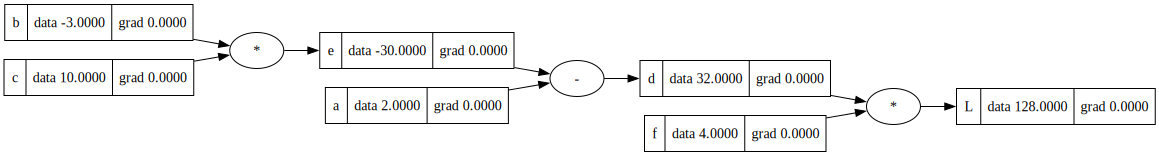

In [26]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')  
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

draw_dot(L)

In [22]:
#back prop (numerical gradient check)
def calc():
    h = 0.001
    a = Value(2, label="a")
    b = Value(-3, label="b")
    c = Value(10, label="c")
    e = b*c; e.label = "e"
    d = a-e; d.label = "d" #a.__sub__(b.__mul__(c))
    f = Value(4, label="f")
    L = d * f; L.label = "L"
    L1 = L.data
    
    a = Value(2, label="a")
    b = Value(-3, label="b")
    c = Value(10, label="c")
    e = b*c; e.label = "e"
    e.data += h 
    d = a-e; d.label = "d" #a.__sub__(b.__mul__(c))
    f = Value(4, label="f")
    L = d * f; L.label = "L"
    L2 = L.data
    
    print((L2-L1)/h)

calc()

-4.0000000000048885


```
think of finding dl/da = dl/dd * (dd/da => local gradient) 
and since 'a' forms 'd' through a simple '-' operation, dd/da is 1,
and dl/dd is routed through to dl/da as 1 multiplies dl/dd


In [68]:
#implementing a simple neuron and a tanh activation layer
x1 = Value(2, label="x1")
x2 = Value(1.2, label="x2")
w1 = Value(1.4, label="w1")
w2 = Value(2.1, label="w2")
x1w1 = x1 * w1; x1w1.label= "x1w1"
x2w2 = x2 * w2; x2w2.label= "x2w2"
b = Value(-2.3, label="b")
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label =  "out"


In [84]:
#calc gradient
def calc():
    h = 0.001
    x1 = Value(2, label="x1")
    x2 = Value(1.2, label="x2")
    w1 = Value(1.4, label="w1")
    w2 = Value(2.1, label="w2")
    x1w1 = x1 * w1; x1w1.label= "x1w1"
    x2w2 = x2 * w2; x2w2.label= "x2w2"
    b = Value(-2.3, label="b")
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
    n = x1w1x2w2 + b; n.label = "n"
    o = n.tanh(); o.label =  "out"
    L1 = o.data    
    
    x1 = Value(2, label="x1")
    x2 = Value(1.2, label="x2")
    w1 = Value(1.4, label="w1")
    w2 = Value(2.1, label="w2")
    x1.data+=h
    x1w1 = x1 * w1; x1w1.label= "x1w1"
    x2w2 = x2 * w2; x2w2.label= "x2w2"
    b = Value(-2.3, label="b")
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
    n = x1w1x2w2 + b; n.label = "n"
    o = n.tanh(); o.label =  "out"
    L2 = o.data
    
    print((L2-L1)/h)
    
calc()

0.013254954295494059


In [80]:
o.grad = 1.0
n.grad = 0.00947
x1w1x2w2.grad = 0.00947
b.grad = 0.00947
x1w1.grad = 0.00947
x2w2.grad = 0.00947
w2.grad = 0.01136
w1.grad = 0.0189
x1.grad = 0.01325
x2.grad = 0.01986

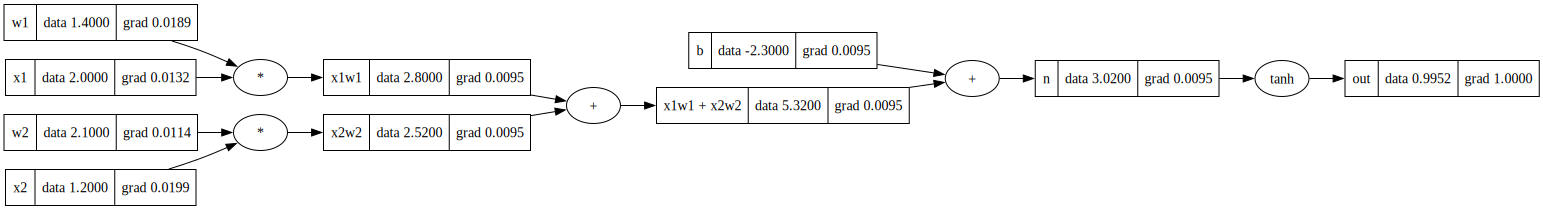

In [81]:
draw_dot(o)